# 03: Using and checking `src/data_loader.py`

Two purposes:

1. **How to use the loader**, both from a notebook and from the command line.
2. **Sanity checks on what it produces**, so that a silent problem in the data shows up here rather than as a mysteriously bad filter on Day 5.

These are checks, not unit tests. Proper `pytest` tests for the filter's predict and update steps live in `tests/` and come later. The difference is that a unit test asserts on behaviour you control, while these cells assert on properties of someone else's recorded data.

## Importing from `src/`

A notebook in `notebooks/` cannot import from `src/` by default, because Python looks in the directory of the running file and in the installed packages. The repository root is neither.

The fix is to put the repository root on `sys.path` first. After that, `src` is treated as a package and `from src.data_loader import ...` works.

`%autoreload` is worth having here: it re-imports changed modules before each cell runs, so editing `src/data_loader.py` takes effect without restarting the kernel.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_loader import (
    PROCESSED,
    RAW,
    SEQUENCES,
    STREAMS,
    load_sequence,
    read_stream,
    write_parquet,
)

print(f"repo       {REPO}")
print(f"sequences  {list(SEQUENCES)}")
print(f"streams    {list(STREAMS)}")

repo       /Users/xinyue/repos/imu-gnss-localization
sequences  ['Urban03', 'Urban04', 'Urban05']
streams    ['imu', 'gnss', 'odometry', 'reference', 'reference_stdev']


## What the module offers

| Name | What it is |
|---|---|
| `SEQUENCES` | short name to run directory, e.g. `"Urban04"` |
| `STREAMS` | stream name to `(bag file, topic, extractor function)` |
| `read_stream(run_dir, bag, topic, extract)` | decode one topic into a DataFrame |
| `load_sequence(name)` | all five streams of one sequence, sharing a time origin |
| `write_parquet(name, tables)` | write them to `data/processed/<name>/` |
| `RAW`, `PROCESSED` | the two data directories |

### Three ways to get at the data

**From the command line**, which is the normal way to produce the Parquet files:

```bash
python src/data_loader.py --sequence Urban04
```

**From Python, re-reading the bags.** Takes a few seconds, and is what you want when changing an extractor.

**From the Parquet files.** Near-instant, and what every downstream notebook should do. Re-reading bags is wasted time once the tables exist.

In [2]:
# Route 2: decode the bags. A few seconds.
tables = load_sequence("Urban04")

for name, df in tables.items():
    span = df["t"].iloc[-1] - df["t"].iloc[0]
    print(f"{name:16s} {len(df):7d} rows  {span:7.1f} s  {(len(df) - 1) / span:6.1f} Hz")
    print(f"{'':16s} {list(df.columns)}")

imu               106500 rows   1065.0 s   100.0 Hz
                 ['t_ns', 't', 'wx', 'wy', 'wz', 'ax', 'ay', 'az']
gnss                4260 rows   1064.8 s     4.0 Hz
                 ['t_ns', 't', 'lat', 'lon', 'alt', 'var_e', 'var_n', 'var_u', 'cov_type', 'status', 'service']
odometry           17751 rows   1064.9 s    16.7 Hz
                 ['t_ns', 't', 'speed']
reference          53251 rows   1065.0 s    50.0 Hz
                 ['t_ns', 't', 'lat', 'lon', 'height', 'v_e', 'v_n', 'v_u', 'roll', 'pitch', 'azimuth', 'status']
reference_stdev     1066 rows   1065.0 s     1.0 Hz
                 ['t_ns', 't', 'lat_stdev', 'lon_stdev', 'height_stdev', 'azimuth_stdev', 'roll_stdev', 'pitch_stdev', 'pos_type', 'ins_status']


In [3]:
# Route 3: read what is already on disk. Milliseconds.
# This is how frames.py, dead_reckoning.py and every later notebook should load data.

def read_processed(sequence: str) -> dict[str, pd.DataFrame]:
    return {
        path.stem: pd.read_parquet(path)
        for path in sorted((PROCESSED / sequence).glob("*.parquet"))
    }


from_disk = read_processed("Urban04")
print(f"streams on disk: {list(from_disk)}")
from_disk["gnss"].head(3)

streams on disk: ['gnss', 'imu', 'odometry', 'reference', 'reference_stdev']


,t_ns,t,lat,lon,alt,var_e,var_n,var_u,cov_type,status,service
0,1698855377886283831,0.067997,44.238515,-76.500415,72.849,0.114921,0.114921,0.249001,2,0,0
1,1698855378145290177,0.327004,44.238515,-76.500415,72.828,0.115600,0.115600,0.250000,2,0,0
2,1698855378403323766,0.585037,44.238515,-76.500415,72.813,0.115600,0.115600,0.251001,2,0,0


## Checks

Each of these catches a specific way the data could be quietly wrong. The point is not that they pass today, it is that they will fail loudly if a future change breaks something.

`assert` is the right tool: a failing assertion stops the notebook at the line that is wrong, instead of letting a bad table flow downstream.

In [4]:
# 1. Time is strictly increasing in every stream. Out-of-order timestamps
#    would break any join, and a duplicate means a message was counted twice.
for name, df in tables.items():
    assert df["t_ns"].is_monotonic_increasing, f"{name}: t_ns not sorted"
    assert df["t_ns"].is_unique, f"{name}: duplicate timestamps"
print("time is sorted and unique in all streams")

# 2. Decoding the bags and reading the Parquet give the same thing.
for name in tables:
    pd.testing.assert_frame_equal(tables[name], from_disk[name])
print("bags and Parquet agree exactly")

# 3. No missing values anywhere.
for name, df in tables.items():
    assert not df.isna().any().any(), f"{name}: contains NaN"
print("no NaNs")

time is sorted and unique in all streams
bags and Parquet agree exactly
no NaNs


In [5]:
# 4. The shared time origin works: exactly one stream starts at zero (the
#    earliest), and none starts much later.
starts = {name: df["t"].iloc[0] for name, df in tables.items()}
print("start times (s):", {k: round(v, 4) for k, v in starts.items()})
assert min(starts.values()) == 0.0
assert max(starts.values()) < 1.0, "a stream starts more than 1 s after the others"

# 5. All streams cover the same window, so nothing was truncated.
ends = {name: df["t"].iloc[-1] for name, df in tables.items()}
print("end times   (s):", {k: round(v, 1) for k, v in ends.items()})
assert max(ends.values()) - min(ends.values()) < 1.0

start times (s): {'imu': np.float64(0.0073), 'gnss': np.float64(0.068), 'odometry': np.float64(0.0259), 'reference': np.float64(0.0), 'reference_stdev': np.float64(0.0019)}
end times   (s): {'imu': np.float64(1065.0), 'gnss': np.float64(1064.9), 'odometry': np.float64(1065.0), 'reference': np.float64(1065.0), 'reference_stdev': np.float64(1065.0)}


In [6]:
# 6. Physical plausibility. These catch a unit error, which is the most
#    likely real bug in a loader.
imu, gnss, odo, ref = (tables[k] for k in ("imu", "gnss", "odometry", "reference"))

g = np.linalg.norm(imu[["ax", "ay", "az"]].to_numpy(), axis=1)
print(f"accelerometer magnitude: mean {g.mean():.3f} m/s^2  (should be near 9.81)")
assert 9.5 < g.mean() < 10.1, "accelerometer is not reading roughly 1 g on average"

gyro_max = np.abs(imu[["wx", "wy", "wz"]].to_numpy()).max()
print(f"max |gyro|: {gyro_max:.3f} rad/s = {np.degrees(gyro_max):.1f} deg/s")
assert gyro_max < 2.0, "gyro may be in deg/s rather than rad/s"

print(f"speed: max {odo['speed'].max():.1f} m/s = {odo['speed'].max() * 3.6:.1f} km/h")
assert odo["speed"].max() < 40, "speed looks like km/h, not m/s"
assert odo["speed"].min() >= 0

# Reported GNSS covariance must be usable, not a block of zeros.
assert (gnss["cov_type"] == 2).all(), "covariance is not 'diagonal known' everywhere"
assert (gnss["var_e"] > 0).all(), "zero covariance reported"
print(f"GNSS sigma_e: median {np.sqrt(gnss['var_e']).median():.2f} m")

print(f"reference status values: {sorted(ref['status'].unique())}  (3 = INS_SOLUTION_GOOD)")

accelerometer magnitude: mean 9.867 m/s^2  (should be near 9.81)
max |gyro|: 0.463 rad/s = 26.5 deg/s
speed: max 12.5 m/s = 45.0 km/h
GNSS sigma_e: median 0.47 m
reference status values: [np.int64(3)]  (3 = INS_SOLUTION_GOOD)


In [7]:
# 7. The GNSS input and the reference describe the same vehicle. A gross
#    frame or sign error would appear as a large constant offset.
lat0 = ref["lat"].iloc[0]
north_offset = (gnss["lat"].iloc[0] - lat0) * 111_320
east_offset = (gnss["lon"].iloc[0] - ref["lon"].iloc[0]) * 111_320 * np.cos(np.radians(lat0))
print(f"first-sample offset, GNSS vs reference: {north_offset:+.2f} m north, {east_offset:+.2f} m east")
assert abs(north_offset) < 50 and abs(east_offset) < 50, "GNSS and reference disagree grossly"

# An offset of a metre or two is expected and is not an error: the Xsens
# antenna and the NovAtel antenna sit at different points on the roof. That
# lever arm is a frames.py problem, not a loader problem.

first-sample offset, GNSS vs reference: +0.75 m north, -0.88 m east


## A first look

Numbers passing assertions is reassuring. Seeing the drive is more convincing, and this is the first picture of the actual problem.

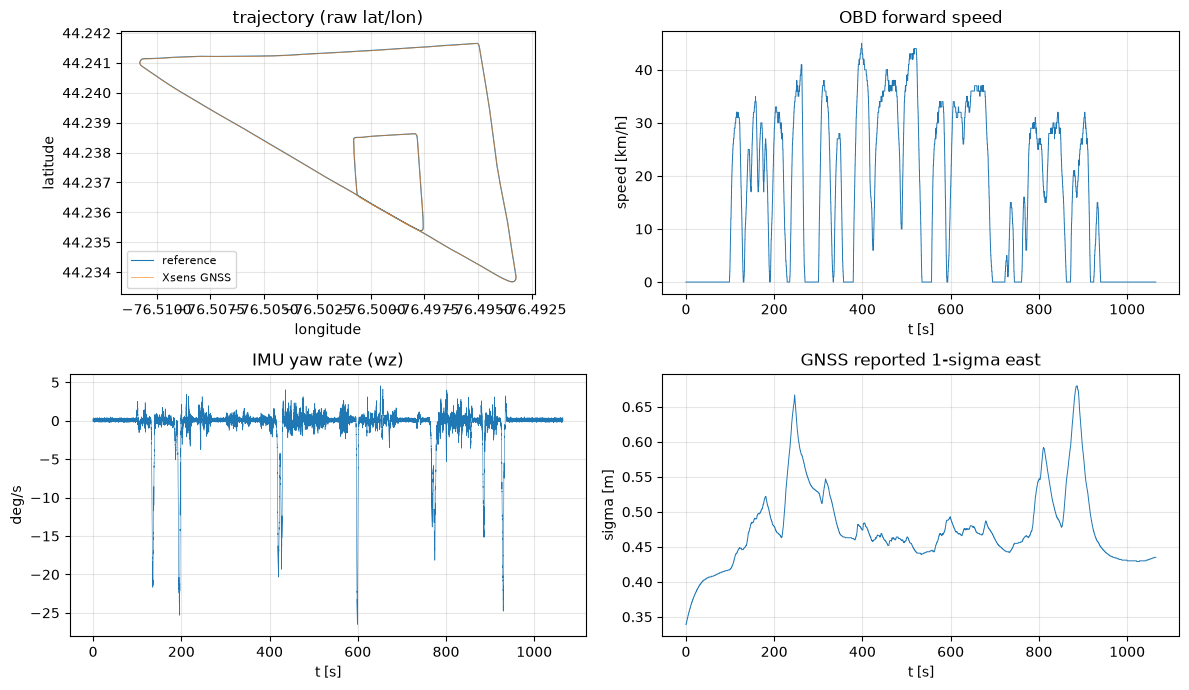

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Raw track in degrees. Not a map: this is pre-frames.py, so it is only a
# shape check. Proper local ENU conversion is the next piece of work.
axes[0, 0].plot(ref["lon"], ref["lat"], lw=0.8, label="reference")
axes[0, 0].plot(gnss["lon"], gnss["lat"], lw=0.6, alpha=0.7, label="Xsens GNSS")
axes[0, 0].set(title="trajectory (raw lat/lon)", xlabel="longitude", ylabel="latitude")
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_aspect(1 / np.cos(np.radians(ref["lat"].mean())))

axes[0, 1].plot(odo["t"], odo["speed"] * 3.6, lw=0.7)
axes[0, 1].set(title="OBD forward speed", xlabel="t [s]", ylabel="speed [km/h]")

# Yaw rate drives heading in the process model, so it is the single most
# important IMU channel for this project.
axes[1, 0].plot(imu["t"], np.degrees(imu["wz"]), lw=0.4)
axes[1, 0].set(title="IMU yaw rate (wz)", xlabel="t [s]", ylabel="deg/s")

axes[1, 1].plot(gnss["t"], np.sqrt(gnss["var_e"]), lw=0.7)
axes[1, 1].set(title="GNSS reported 1-sigma east", xlabel="t [s]", ylabel="sigma [m]")

for ax in axes.ravel():
    ax.grid(alpha=0.3)
fig.tight_layout()

## The stationary period

Every NavINST trajectory begins and ends with roughly two minutes stationary. That window is worth finding now, because three things depend on it:

- **Turn-on gyro bias.** The mean gyro output while genuinely still *is* the bias. This gives a measured number for `CLAUDE.md` §6, which currently borrows 0.5°/s from the wrong sensor.
- **Initial covariance $P_0$.** The scatter of those same samples.
- **Empirical GNSS noise.** Position scatter while parked is a better basis for $R$ than a datasheet.

Detect it from the odometer rather than the IMU: wheel speed is exactly zero when parked, whereas the IMU always shows noise.

In [9]:
moving = odo.loc[odo["speed"] > 0.1, "t"]
t_start, t_end = moving.iloc[0], moving.iloc[-1]
print(f"vehicle moves from t = {t_start:.1f} s to t = {t_end:.1f} s")
print(f"stationary at the start: {t_start:.1f} s")
print(f"stationary at the end:   {odo['t'].iloc[-1] - t_end:.1f} s")

still = imu[imu["t"] < t_start]
print(f"\n{len(still)} IMU samples in the initial stationary window")
print("mean gyro while stationary, i.e. the turn-on bias:")
for axis in ("wx", "wy", "wz"):
    mean, sd = still[axis].mean(), still[axis].std()
    print(f"  {axis}: {np.degrees(mean):+.4f} deg/s   (sample sd {np.degrees(sd):.4f} deg/s)")

vehicle moves from t = 98.6 s to t = 939.7 s
stationary at the start: 98.6 s
stationary at the end:   125.3 s

9860 IMU samples in the initial stationary window
mean gyro while stationary, i.e. the turn-on bias:
  wx: -0.0027 deg/s   (sample sd 0.1170 deg/s)
  wy: -0.2110 deg/s   (sample sd 0.1310 deg/s)
  wz: +0.0977 deg/s   (sample sd 0.1012 deg/s)


---

### Next

`src/frames.py`: WGS84 to a local ENU frame with `pymap3d`, origin at the first reference sample. Nothing can be compared in metres until that exists, and E1 needs it.